In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from config import ExperimentConfig, INPUT_COLS
from preprocessing import add_features, apply_scale, fit_scale_stats, split_time
from algorithm import ArxSpec, fit_arx
from evaluation import evaluate_model

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = PROJECT_ROOT / "data" / "mini_greenhouse_5s_data.csv"
MODEL_PATH = PROJECT_ROOT / "result" / "arx_5s_model.json"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)

Project root: C:\Users\minht\OneDrive\Desktop\ARX-Model\ARX_DO_BY_SELF
Data path: C:\Users\minht\OneDrive\Desktop\ARX-Model\ARX_DO_BY_SELF\data\mini_greenhouse_5s_data.csv


In [2]:
data_df = pd.read_csv(DATA_PATH, parse_dates=["Timestamp"])
featured_df = add_features(data_df)
cfg = ExperimentConfig()
train_df, val_df, test_df = split_time(featured_df, cfg)

with open(MODEL_PATH, "r", encoding="utf-8") as f:
    model_artifact = json.load(f)

spec = ArxSpec(**model_artifact["spec"])

summary = pd.DataFrame([
    {"Split": "Train", "Rows": len(train_df), "Days": train_df["Timestamp"].dt.normalize().nunique(), "Start": train_df["Timestamp"].min(), "End": train_df["Timestamp"].max()},
    {"Split": "Validation", "Rows": len(val_df), "Days": val_df["Timestamp"].dt.normalize().nunique(), "Start": val_df["Timestamp"].min(), "End": val_df["Timestamp"].max()},
    {"Split": "Test", "Rows": len(test_df), "Days": test_df["Timestamp"].dt.normalize().nunique(), "Start": test_df["Timestamp"].min(), "End": test_df["Timestamp"].max()},
])
display(summary)

spec_table = pd.DataFrame([
    ["na", spec.na],
    ["nb", spec.nb],
    ["nk", spec.nk],
    ["alpha", spec.alpha],
], columns=["Tham số", "Giá trị"])
display(spec_table)

,Split,Rows,Days,Start,End
0,Train,138240,8,2026-04-08,2026-04-15 23:59:55
1,Validation,34560,2,2026-04-16,2026-04-17 23:59:55
2,Test,34560,2,2026-04-18,2026-04-19 23:59:55


,Tham số,Giá trị
0,na,96.0000
1,nb,16.0000
2,nk,2.0000
3,alpha,10.0000


In [3]:
raw_cols = ("Temperature", "Humidity", "Light", "Drip", "Mist", "Fan")

feature_sets = {
    "Raw only": raw_cols,
    "Raw + env derived": raw_cols + ("Light_log", "Air_Dryness", "Temp_x_Air_Dryness"),
    "Raw + time cycle": raw_cols + ("Hour_sin", "Hour_cos", "Day_sin", "Day_cos"),
    "Full features": tuple(INPUT_COLS),
}

feature_set_table = pd.DataFrame([
    {"Feature set": name, "Số input": len(cols), "Input columns": ", ".join(cols)}
    for name, cols in feature_sets.items()
])
display(feature_set_table)

,Feature set,Số input,Input columns
0,Raw only,6,"Temperature, Humidity, Light, Drip, Mist, Fan"
1,Raw + env derived,9,"Temperature, Humidity, Light, Drip, Mist, Fan,..."
2,Raw + time cycle,10,"Temperature, Humidity, Light, Drip, Mist, Fan,..."
3,Full features,16,"Temperature, Humidity, Light, Drip, Mist, Fan,..."


In [4]:
def physical_clip(stats: dict[str, tuple[float, float]], cfg: ExperimentConfig) -> tuple[float, float]:
    mean, std = stats["Soil_Moisture"]
    low = max(0.0, cfg.soil_low_sp - cfg.soil_clip_margin)
    high = min(100.0, cfg.soil_high_sp + cfg.soil_clip_margin)
    return (float((low - mean) / std), float((high - mean) / std))


def fit_and_evaluate_feature_set(name: str, input_cols: tuple[str, ...]) -> dict[str, float | str | int]:
    stats = fit_scale_stats(train_df, input_cols)
    train_z = apply_scale(train_df, stats)
    val_z = apply_scale(val_df, stats)
    test_z = apply_scale(test_df, stats)
    clip = physical_clip(stats, cfg)

    theta = fit_arx(train_z, spec, input_cols)
    val_eval = evaluate_model(val_z, theta, spec, input_cols, stats, clip, cfg)
    test_eval = evaluate_model(test_z, theta, spec, input_cols, stats, clip, cfg)

    return {
        "Feature set": name,
        "Số input": len(input_cols),
        "Số theta": len(theta),
        "Val FIT 1-step": val_eval["metrics_1step"]["FIT"],
        "Val FIT 20min": val_eval["metrics_20min_chunked"]["FIT"],
        "Val FIT free-run": val_eval["metrics_free_run"]["FIT"],
        "Val RMSE free-run": val_eval["metrics_free_run"]["RMSE"],
        "Test FIT 1-step": test_eval["metrics_1step"]["FIT"],
        "Test FIT 20min": test_eval["metrics_20min_chunked"]["FIT"],
        "Test FIT free-run": test_eval["metrics_free_run"]["FIT"],
        "Test RMSE free-run": test_eval["metrics_free_run"]["RMSE"],
    }

rows = []
for name, cols in feature_sets.items():
    print("Fitting:", name)
    rows.append(fit_and_evaluate_feature_set(name, cols))

ablation_df = pd.DataFrame(rows)
display(ablation_df.round(4))

Fitting: Raw only


Fitting: Raw + env derived


Fitting: Raw + time cycle


Fitting: Full features


,Feature set,Số input,Số theta,Val FIT 1-step,Val FIT 20min,Val FIT free-run,Val RMSE free-run,Test FIT 1-step,Test FIT 20min,Test FIT free-run,Test RMSE free-run
0,Raw only,6,193,95.3322,89.8908,75.0119,0.1409,94.8383,83.2819,72.5280,0.1576
1,Raw + env derived,9,241,95.3320,89.8943,74.8882,0.1416,94.8382,83.2794,72.4450,0.1581
2,Raw + time cycle,10,257,95.3321,89.9520,76.6582,0.1316,94.8383,83.3601,73.9309,0.1496
3,Full features,16,353,95.3316,89.9523,76.4025,0.1330,94.8382,83.3951,74.7286,0.1450


In [5]:
base = ablation_df.loc[ablation_df["Feature set"] == "Raw only"].iloc[0]
comparison_df = ablation_df.copy()
comparison_df["Delta Val FIT free-run"] = comparison_df["Val FIT free-run"] - base["Val FIT free-run"]
comparison_df["Delta Test FIT free-run"] = comparison_df["Test FIT free-run"] - base["Test FIT free-run"]
comparison_df["Test RMSE reduction (%)"] = 100.0 * (base["Test RMSE free-run"] - comparison_df["Test RMSE free-run"]) / base["Test RMSE free-run"]

report_cols = [
    "Feature set",
    "Số input",
    "Số theta",
    "Val FIT free-run",
    "Delta Val FIT free-run",
    "Test FIT free-run",
    "Delta Test FIT free-run",
    "Test RMSE free-run",
    "Test RMSE reduction (%)",
]
display(comparison_df[report_cols].round(4))

,Feature set,Số input,Số theta,Val FIT free-run,Delta Val FIT free-run,Test FIT free-run,Delta Test FIT free-run,Test RMSE free-run,Test RMSE reduction (%)
0,Raw only,6,193,75.0119,0.0000,72.5280,0.0000,0.1576,0.0000
1,Raw + env derived,9,241,74.8882,-0.1238,72.4450,-0.0830,0.1581,-0.3023
2,Raw + time cycle,10,257,76.6582,1.6463,73.9309,1.4029,0.1496,5.1066
3,Full features,16,353,76.4025,1.3906,74.7286,2.2006,0.1450,8.0104


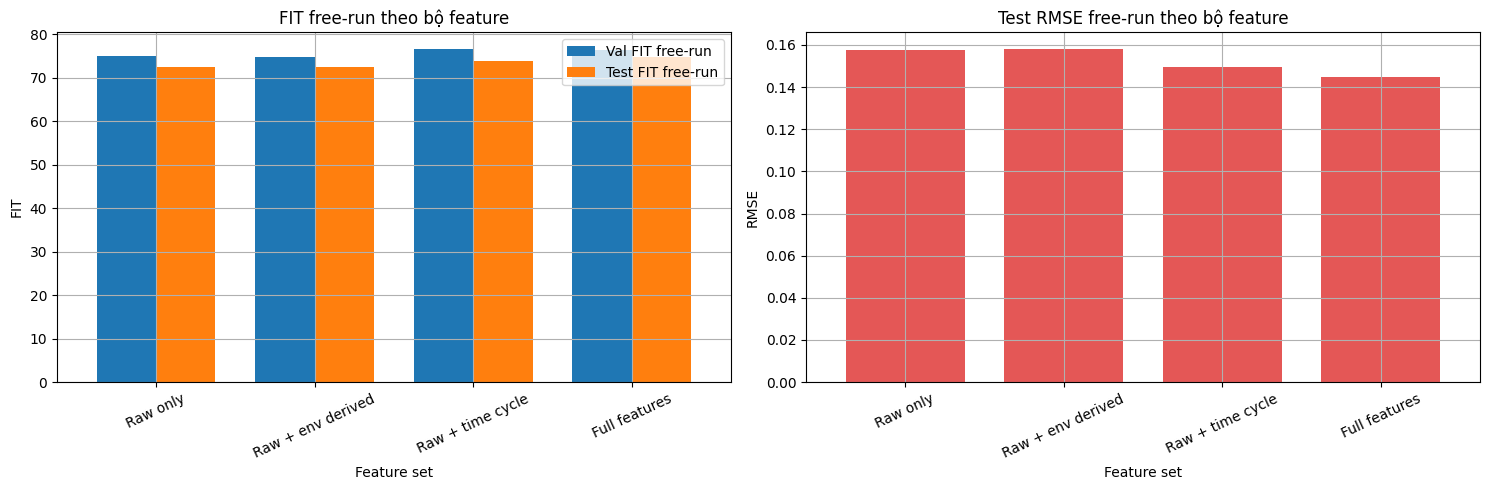

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_df = comparison_df.set_index("Feature set")

plot_df[["Val FIT free-run", "Test FIT free-run"]].plot(kind="bar", ax=axes[0], width=0.75)
axes[0].set_title("FIT free-run theo bộ feature")
axes[0].set_ylabel("FIT")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="")

plot_df["Test RMSE free-run"].plot(kind="bar", ax=axes[1], color="#E45756", width=0.75)
axes[1].set_title("Test RMSE free-run theo bộ feature")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [7]:
extra_features = [col for col in INPUT_COLS if col not in raw_cols]

single_rows = []
for feature in extra_features:
    name = f"Raw + {feature}"
    cols = raw_cols + (feature,)
    print("Fitting:", name)
    row = fit_and_evaluate_feature_set(name, cols)
    row["Feature thêm"] = feature
    single_rows.append(row)

single_feature_df = pd.DataFrame(single_rows)
single_feature_df["Delta Val FIT free-run"] = single_feature_df["Val FIT free-run"] - base["Val FIT free-run"]
single_feature_df["Delta Test FIT free-run"] = single_feature_df["Test FIT free-run"] - base["Test FIT free-run"]
single_feature_df["Test RMSE reduction (%)"] = 100.0 * (base["Test RMSE free-run"] - single_feature_df["Test RMSE free-run"]) / base["Test RMSE free-run"]

single_report_cols = [
    "Feature thêm",
    "Số input",
    "Số theta",
    "Val FIT free-run",
    "Delta Val FIT free-run",
    "Test FIT free-run",
    "Delta Test FIT free-run",
    "Test RMSE free-run",
    "Test RMSE reduction (%)",
]

single_feature_report = single_feature_df[single_report_cols].sort_values("Delta Test FIT free-run", ascending=False)
display(single_feature_report.round(4))

Fitting: Raw + Light_log


Fitting: Raw + Temp_x_Humidity


Fitting: Raw + Temp_x_Light


Fitting: Raw + Humidity_x_Light


Fitting: Raw + Air_Dryness


...

Fitting: Raw + Hour_sin


Fitting: Raw + Hour_cos


Fitting: Raw + Day_sin


Fitting: Raw + Day_cos


,Feature thêm,Số input,Số theta,Val FIT free-run,Delta Val FIT free-run,Test FIT free-run,Delta Test FIT free-run,Test RMSE free-run,Test RMSE reduction (%)
9,Day_cos,7,209,75.2913,0.2794,74.2497,1.7217,0.1477,6.2672
8,Day_sin,7,209,76.6570,1.6451,73.0745,0.5465,0.1545,1.9892
5,Temp_x_Air_Dryness,7,209,75.0149,0.0030,72.7230,0.1950,0.1565,0.7099
1,Temp_x_Humidity,7,209,75.0189,0.0070,72.7103,0.1823,0.1566,0.6635
4,Air_Dryness,7,209,74.9977,-0.0142,72.5142,-0.0138,0.1577,-0.0502
3,Humidity_x_Light,7,209,75.0533,0.0414,72.3939,-0.1341,0.1584,-0.4881
6,Hour_sin,7,209,75.0774,0.0654,72.3699,-0.1581,0.1585,-0.5754
0,Light_log,7,209,74.9706,-0.0413,72.3035,-0.2245,0.1589,-0.8171
2,Temp_x_Light,7,209,74.9506,-0.0613,72.3013,-0.2267,0.1589,-0.8252
7,Hour_cos,7,209,74.8092,-0.2028,71.8712,-0.6568,0.1614,-2.3909


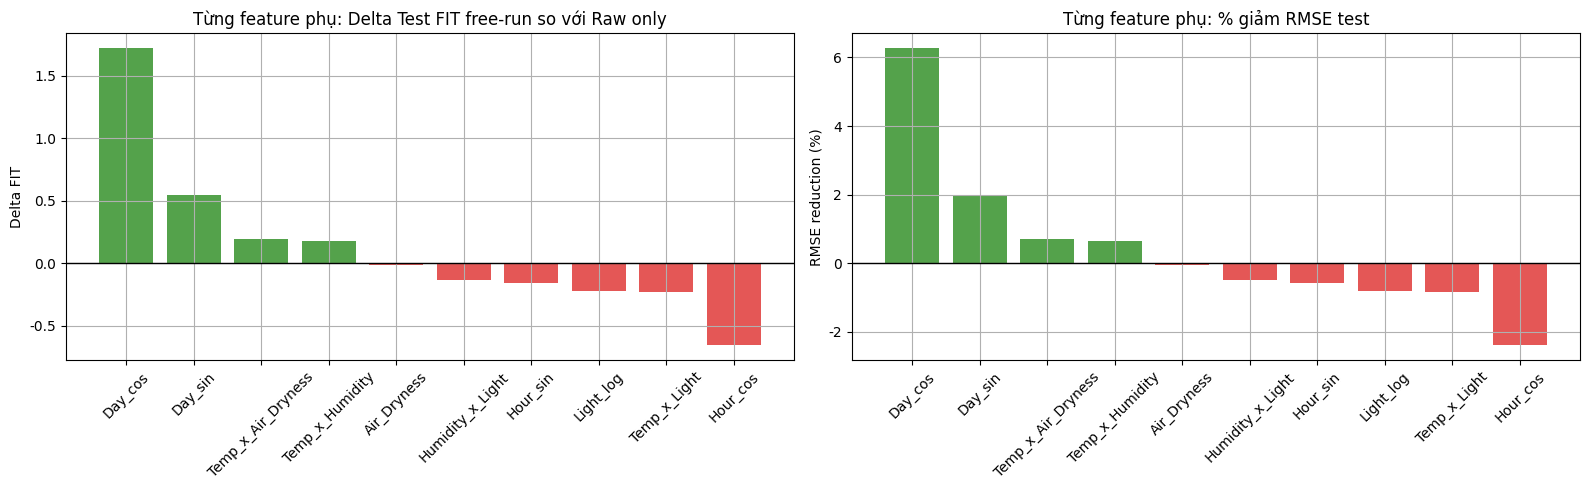

In [8]:
plot_single = single_feature_report.set_index("Feature thêm")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = np.where(plot_single["Delta Test FIT free-run"] >= 0, "#54A24B", "#E45756")
axes[0].bar(plot_single.index, plot_single["Delta Test FIT free-run"], color=colors)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Từng feature phụ: Delta Test FIT free-run so với Raw only")
axes[0].set_ylabel("Delta FIT")
axes[0].tick_params(axis="x", rotation=45)

colors_rmse = np.where(plot_single["Test RMSE reduction (%)"] >= 0, "#54A24B", "#E45756")
axes[1].bar(plot_single.index, plot_single["Test RMSE reduction (%)"], color=colors_rmse)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Từng feature phụ: % giảm RMSE test")
axes[1].set_ylabel("RMSE reduction (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()